# Volve 2 — PVT characterization, black oil, reservoir history, and forecast

**Notebook 2 of 5 — integrated Volve field evaluation**

The authoritative input boundary is Equinor's Volve Data Village
listing in Databricks Marketplace. The notebook can read an
installed Unity Catalog volume directly or securely download only
selected files into Colab. It never stores credentials or
redistributes the complete Volve package.

A deterministic teaching fixture is used during unauthenticated
clean-runtime validation. Every such result is marked
**DEMONSTRATION_FALLBACK** and must not be described as measured
Volve data, a history match, a reserves statement, or certified
design.


## Learning outcomes and engineering decisions

            - select Marketplace PVT, Eclipse/OPM, and production assets
- characterize a reservoir fluid and C7+ fractions in NeqSim
- generate differential-liberation and black-oil source tables
- audit an OPM Flow deck and inspect summary/restart result contracts
- compare observed history with a transparent material-balance screen
- deliver pressure, rates, GOR, water cut, and uncertainty to wells and facilities

            The discipline result is written as a versioned handoff contract.
            Downstream notebooks consume quantities with names, units, source
            mode, assumptions, uncertainty, and validity limits rather than
            relying on hidden notebook state.


## End-to-end architecture

The series follows one controlled chain:

**Marketplace assets → seismic and logs → static model → PVT and
reservoir forecast → well and SURF deliverability → facilities and
export constraints → field scenarios and decisions**

Specialist tools retain their roles. segyio handles SEG-Y, lasio
and dlisio handle logs, OPM Flow or its deck interface handles
dynamic reservoir simulation, resdata inspects OPM results, and
NeqSim owns fluid characterization, PVT, flow assurance, process
simulation, equipment duties, and composable surface streams.


## Data provenance, licence, and claim boundary

Primary sources:

- [Databricks Marketplace: Equinor Volve Data Village](https://marketplace.databricks.com/details/5c3558ef-315c-44dd-baef-7062ac301f22/Equinor-ASA_Volve-Data-Village)
- [Equinor Volve data sharing](https://www.equinor.com/energy/volve-data-sharing)
- [Equinor Volve data licence](https://www.equinor.com/content/dam/statoil/documents/what-we-do/Equinor-HRS-Terms-and-conditions-for-licence-to-data-Volve.pdf)
- [Databricks Marketplace access guidance](https://docs.databricks.com/aws/en/marketplace/get-started-consumer)
- [Databricks Files API for Unity Catalog volumes](https://docs.databricks.com/aws/en/volumes/volume-files)

The raw package remains in the user's read-only Marketplace share.
Generated working tables contain only selected or derived values
and retain the source path and digest when real files are used.


## Clean-runtime setup and NeqSim source policy

Normal Colab execution clones current equinor/neqsim master,
records the resolved commit, builds the runtime JAR, adds it to the
JVM before importing NeqSim, and verifies the loaded class origin.
The Python package remains the JPype bridge. Local validation can
set VOLVE_VALIDATION_MODE=1 to use the pinned 3.17.0 release JAR;
that mode validates notebook logic but does not replace the
required current-master and Databricks acceptance run.


In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
import hashlib
import os
from pathlib import Path
import platform
import shutil
import subprocess
import sys


VALIDATION_MODE = os.environ.get("VOLVE_VALIDATION_MODE") == "1"
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
NEQSIM_REPOSITORY_URL = "https://github.com/equinor/neqsim"

if not VALIDATION_MODE:
    required = {
        "neqsim": "3.17.0",
        "databricks-sdk": "0.72.0",
        "segyio": "1.9.14",
        "lasio": "0.32",
        "dlisio": "1.0.3",
    }
    specifications = [
        f"{package}=={required_version}"
        for package, required_version in required.items()
    ]
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *specifications],
        check=True,
        timeout=900,
    )
    source_dir = Path("/content/neqsim-master")
    if not source_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                NEQSIM_REPOSITORY_URL,
                str(source_dir),
            ],
            check=True,
            timeout=300,
        )
    resolved_commit = subprocess.run(
        ["git", "-C", str(source_dir), "rev-parse", "HEAD"],
        capture_output=True,
        check=True,
        text=True,
        timeout=60,
    ).stdout.strip()
    subprocess.run(
        [str(source_dir / "mvnw"), "-q", "-DskipTests", "package"],
        check=True,
        cwd=source_dir,
        timeout=1800,
    )
    runtime_jars = sorted((source_dir / "target").glob("neqsim-*-jar-with-dependencies.jar"))
    if not runtime_jars:
        raise RuntimeError("Current-master NeqSim runtime JAR was not built.")
    os.environ["NEQSIM_JVM_AUTOSTART"] = "false"
    import jpype

    jpype.addClassPath(str(runtime_jars[-1]))
    jpype.startJVM(convertStrings=False)
else:
    resolved_commit = "release-3.17.0-validation-runtime"

from neqsim import jneqsim
from neqsim.thermo import TPflash

protection = (
    jneqsim.thermo.system.SystemSrkEos.class_
    .getProtectionDomain()
    .getCodeSource()
)
runtime_origin = str(protection.getLocation()) if protection else "bundled JAR"
print(
    {
        "Python": platform.python_version(),
        "NeqSim bridge": version("neqsim"),
        "source ref": NEQSIM_SOURCE_REF,
        "resolved commit": resolved_commit,
        "runtime origin": runtime_origin,
        "validation mode": VALIDATION_MODE,
    }
)


{'Python': '3.12.13', 'NeqSim bridge': '3.17.0', 'source ref': 'master', 'resolved commit': 'release-3.17.0-validation-runtime', 'runtime origin': 'None', 'validation mode': True}


In [2]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

series_dir = Path.cwd()
if not (series_dir / "volve_common.py").is_file():
    repository_dir = Path("/content/NeqSim-Colab")
    if not repository_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/EvenSol/NeqSim-Colab.git",
                str(repository_dir),
            ],
            check=True,
            timeout=300,
        )
    series_dir = (
        repository_dir
        / "notebooks"
        / "fielddevelopment"
        / "volve"
    )
sys.path.insert(0, str(series_dir))

import volve_common as vc

work_dir = Path(
    os.environ.get("VOLVE_WORK_DIR", str(series_dir / "work"))
)
work_dir.mkdir(parents=True, exist_ok=True)
source = vc.resolve_source()
display(vc.source_table(source))


,item,value
0,resolved mode,demonstration-fallback
1,Marketplace listing,https://marketplace.databricks.com/details/5c3...
2,volume root,not mounted
3,credentials,none
4,measured Volve data loaded,False
5,claim boundary,Deterministic teaching fixtures are used. Resu...


## Marketplace ingestion and bounded file selection

The listing contains tables and non-tabular files. Large SEG-Y,
DLIS, Eclipse restart, and report assets are normally shared as
Unity Catalog volume files. Colab therefore uses the Databricks
Files API and downloads only paths selected for the calculation.
The complete 5 TB-scale package is never copied.

Set VOLVE_DATA_MODE=marketplace and either:

1. point VOLVE_VOLUME_ROOT to an existing mounted or exported
   Marketplace directory; or
2. set VOLVE_REMOTE_VOLUME_ROOT to the Unity Catalog volume path and
   store DATABRICKS_HOST and DATABRICKS_TOKEN as Colab secrets.


In [3]:
if source.mode == "marketplace-local-volume":
    inventory = vc.inventory_local_volume(Path(source.volume_root))
elif source.mode == "marketplace-remote-volume":
    inventory = vc.list_remote_directory(source.volume_root)
else:
    inventory = vc.demonstration_inventory()

domain_summary = (
    inventory.groupby("domain", as_index=False)
    .agg(file_count=("relative_path", "size"), bytes=("bytes", "sum"))
    .sort_values("bytes", ascending=False)
)
domain_summary["size_GB"] = domain_summary["bytes"] / 1.0e9
display(domain_summary[["domain", "file_count", "size_GB"]])
display(inventory.head(12))


,domain,file_count,size_GB
4,seismic,1,3.20000
3,reservoir-model,3,2.91180
6,well-log,2,0.32420
5,static-model,1,0.00850
0,facilities-document,1,0.00530
1,production-history,1,0.00240
7,well-trajectory,1,0.00064
2,pvt,1,0.00012


,relative_path,suffix,bytes,domain
0,Seismic/ST0202/stacked_volume.sgy,.sgy,3200000000,seismic
1,Well_logs/15_9-F-1_C/composite.las,.las,4200000,well-log
2,Well_logs/15_9-F-14/formation_eval.dlis,.dlis,320000000,well-log
3,Reservoir_model/VOLVE.DATA,.data,1800000,reservoir-model
4,Reservoir_model/VOLVE.EGRID,.egrid,210000000,reservoir-model
5,Reservoir_model/VOLVE.UNRST,.unrst,2700000000,reservoir-model
6,Production/volve_daily_production.xlsx,.xlsx,2400000,production-history
7,Wells/well_trajectories.csv,.csv,640000,well-trajectory
8,PVT/representative_fluid_composition.xlsx,.xlsx,120000,pvt
9,Static_model/top_hugin_surface.txt,.txt,8500000,static-model


## 1. Upstream handoff and Marketplace reservoir assets

A complete real-data run reads the geoscience handoff, the selected
fluid composition or PVT report, one OPM/Eclipse deck and its
include files, and daily or monthly production history from the
Marketplace share. Environment variables VOLVE_PVT_PATH,
VOLVE_ECLIPSE_DATA_PATH, and VOLVE_PRODUCTION_PATH make selection
explicit when several candidates exist.


In [4]:
upstream_path = work_dir / "01_geoscience_static_model.json"
if upstream_path.is_file():
    geoscience_contract = vc.read_contract(upstream_path)
else:
    fallback_samples = vc.calculate_stoiip_distribution(3000)
    geoscience_contract = {
        "schema_version": vc.SERIES_SCHEMA_VERSION,
        "gross_rock_volume_m3": 110.0e6,
        "stoiip_percentiles_MSm3": {
            "P10_low": float(fallback_samples["stoiip_MSm3"].quantile(0.1)),
            "P50": float(fallback_samples["stoiip_MSm3"].quantile(0.5)),
            "P90_high": float(fallback_samples["stoiip_MSm3"].quantile(0.9)),
        },
    }
print(geoscience_contract["stoiip_percentiles_MSm3"])


{'P10_low': 7.402027410974053, 'P50': 10.342571587515575, 'P90_high': 14.152791367187296}


In [5]:
if source.measured_data_loaded:
    pvt_path = vc.select_asset(
        inventory,
        "pvt",
        environment_name="VOLVE_PVT_PATH",
    )
    reservoir_path = vc.select_asset(
        inventory,
        "reservoir-model",
        environment_name="VOLVE_ECLIPSE_DATA_PATH",
    )
    production_path = vc.select_asset(
        inventory,
        "production-history",
        environment_name="VOLVE_PRODUCTION_PATH",
    )
    print(
        {
            "PVT": pvt_path,
            "reservoir": reservoir_path,
            "production": production_path,
        }
    )
    raise RuntimeError(
        "The Marketplace acceptance run must parse the selected files "
        "before publishing measured-data results."
    )
production = vc.demo_production_history()
field_history = vc.reservoir_screen(production)
display(production.head())
display(field_history.head())


,date,well,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,on_stream_fraction,data_status
0,2008-02-01,15/9-F-1 C,0.000000,0.000000,0.000000,0.000000,DEMONSTRATION_FALLBACK
1,2008-03-01,15/9-F-1 C,0.000000,0.000000,0.000000,0.000000,DEMONSTRATION_FALLBACK
2,2008-04-01,15/9-F-1 C,0.000000,0.000000,0.000000,0.000000,DEMONSTRATION_FALLBACK
3,2008-05-01,15/9-F-1 C,199.020090,23896.122612,18.971926,0.199020,DEMONSTRATION_FALLBACK
4,2008-06-01,15/9-F-1 C,402.739247,48360.148968,38.745789,0.402739,DEMONSTRATION_FALLBACK


,date,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,liquid_rate_Sm3_day,water_cut_fraction,gor_Sm3_Sm3,elapsed_days,cumulative_oil_MSm3,cumulative_water_MSm3,average_pressure_bara,recovery_fraction
0,2008-02-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,265.000000,0.000000
1,2008-03-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29,0.000000,0.000000,265.000000,0.000000
2,2008-04-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60,0.000000,0.000000,265.000000,0.000000
3,2008-05-01,199.020090,23896.122612,18.971926,217.992016,0.087030,120.068897,90,0.006058,0.000577,264.938128,0.000418
4,2008-06-01,402.739247,48360.148968,38.745789,441.485036,0.087762,120.078064,121,0.018316,0.001757,264.812939,0.001263


## 2. Fluid assay and NeqSim characterization

The teaching assay uses light components, two TBP cuts, SRK, the
classic mixing rule, and volume correction. A measured-data run
must use the sampled composition, separator recombination basis,
plus-fraction molecular weight and density, laboratory temperature,
pressure, and experiment quality. Tuning to CCE, DLE, viscosity, and
density must be documented separately from the raw observations.


In [6]:
reservoir_temperature_c = 97.5
initial_pressure_bara = 260.0
fluid = jneqsim.thermo.system.SystemSrkEos(
    reservoir_temperature_c + 273.15,
    initial_pressure_bara,
)
light_components = [
    ("nitrogen", 0.004),
    ("CO2", 0.003),
    ("methane", 0.402),
    ("ethane", 0.076),
    ("propane", 0.080),
    ("i-butane", 0.012),
    ("n-butane", 0.041),
    ("i-pentane", 0.014),
    ("n-pentane", 0.022),
    ("n-hexane", 0.028),
]
for component_name, mole_fraction in light_components:
    fluid.addComponent(component_name, mole_fraction)
fluid.addTBPfraction("C7", 0.160, 0.115, 0.75)
fluid.addTBPfraction("C10", 0.158, 0.260, 0.88)
fluid.setMixingRule("classic")
fluid.useVolumeCorrection(True)
fluid.setMultiPhaseCheck(True)
fluid.init(0)
composition_sum = sum(value for _, value in light_components) + 0.318
print(
    {
        "composition sum": composition_sum,
        "component count": fluid.getNumberOfComponents(),
        "EOS": "SRK",
        "mixing rule": "classic",
    }
)


{'composition sum': 1.0, 'component count': 12, 'EOS': 'SRK', 'mixing rule': 'classic'}


## 3. Saturation pressure and pressure sweep

A flash solves phase equilibrium at specified pressure and
temperature. The phase fraction $\beta_\alpha$ and density
$\rho_\alpha$ are recorded for each phase. The sweep is a numerical
diagnostic: phase appearance should be coherent and properties
should remain finite.


In [7]:
saturation_calculation = (
    jneqsim.pvtsimulation.simulation.SaturationPressure(fluid.clone())
)
saturation_calculation.setTemperature(reservoir_temperature_c, "C")
saturation_calculation.run()
bubble_pressure_bara = float(
    saturation_calculation.getSaturationPressure()
)

pressure_rows = []
for pressure_bara in np.linspace(40.0, 320.0, 29):
    state = fluid.clone()
    state.setTemperature(reservoir_temperature_c, "C")
    state.setPressure(float(pressure_bara), "bara")
    TPflash(state)
    state.initPhysicalProperties()
    gas_fraction = 0.0
    oil_density = np.nan
    oil_viscosity = np.nan
    if state.hasPhaseType("gas"):
        gas_fraction = state.getPhase("gas").getBeta()
    if state.hasPhaseType("oil"):
        oil_density = state.getPhase("oil").getDensity("kg/m3")
        oil_viscosity = state.getPhase("oil").getViscosity("cP")
    pressure_rows.append(
        {
            "pressure_bara": pressure_bara,
            "gas_mole_fraction": gas_fraction,
            "oil_density_kg_m3": oil_density,
            "oil_viscosity_cP": oil_viscosity,
            "phase_count": state.getNumberOfPhases(),
        }
    )
pressure_sweep = pd.DataFrame(pressure_rows)
print(f"Bubble pressure: {bubble_pressure_bara:.2f} bara")
display(pressure_sweep.head())


Bubble pressure: 178.84 bara


,pressure_bara,gas_mole_fraction,oil_density_kg_m3,oil_viscosity_cP,phase_count
0,40.0,0.478281,720.839977,0.393080,2
1,50.0,0.444619,711.540329,0.363150,2
2,60.0,0.412522,702.997629,0.338329,2
3,70.0,0.381205,694.967941,0.317041,2
4,80.0,0.350152,687.300491,0.298357,2


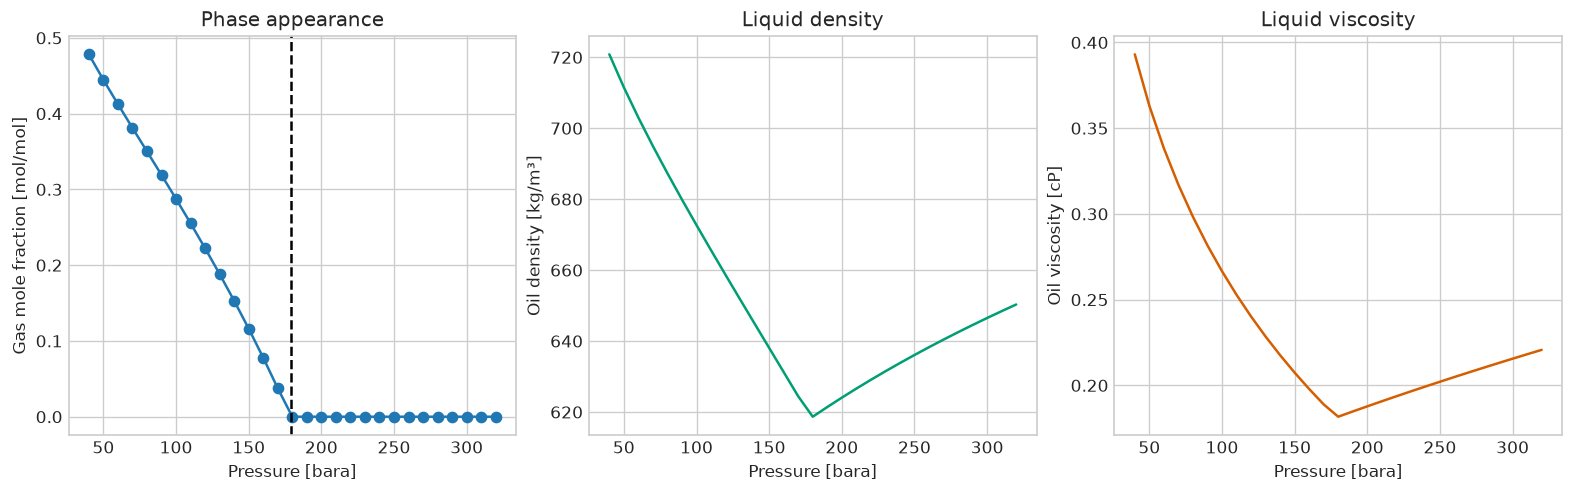

In [8]:
pvt_figure, pvt_axes = plt.subplots(
    1,
    3,
    figsize=(13.0, 4.0),
    constrained_layout=True,
)
pvt_axes[0].plot(
    pressure_sweep["pressure_bara"],
    pressure_sweep["gas_mole_fraction"],
    marker="o",
)
pvt_axes[0].axvline(bubble_pressure_bara, color="black", linestyle="--")
pvt_axes[0].set(
    xlabel="Pressure [bara]",
    ylabel="Gas mole fraction [mol/mol]",
    title="Phase appearance",
)
pvt_axes[1].plot(
    pressure_sweep["pressure_bara"],
    pressure_sweep["oil_density_kg_m3"],
    color="#009E73",
)
pvt_axes[1].set(
    xlabel="Pressure [bara]",
    ylabel="Oil density [kg/m³]",
    title="Liquid density",
)
pvt_axes[2].plot(
    pressure_sweep["pressure_bara"],
    pressure_sweep["oil_viscosity_cP"],
    color="#D55E00",
)
pvt_axes[2].set(
    xlabel="Pressure [bara]",
    ylabel="Oil viscosity [cP]",
    title="Liquid viscosity",
)
plt.show()


## 4. Differential liberation and black-oil source records

Differential liberation removes evolved gas at each pressure step.
The resulting solution GOR, oil formation-volume factor, gas FVF,
densities, and viscosities form the source evidence for PVTO, PVDG,
and PVTW tables. Simulator tables still require ordering,
interpolation, region, and unit checks; copying values into a deck
is not sufficient validation.


In [9]:
dle_pressures_bara = [300.0, 260.0, 230.0, 200.0, 170.0, 120.0, 60.0, 1.01325]
liberation = jneqsim.pvtsimulation.simulation.DifferentialLiberation(
    fluid.clone()
)
liberation.setPressures(dle_pressures_bara)
liberation.setTemperature(reservoir_temperature_c, "C")
liberation.runCalc()
dle_table = pd.DataFrame(
    {
        "pressure_bara": dle_pressures_bara,
        "Rs_Sm3_Sm3": np.asarray(liberation.getRs(), dtype=float),
        "Bo_rm3_Sm3": np.asarray(liberation.getBo(), dtype=float),
        "Bg_rm3_Sm3": np.asarray(liberation.getBg(), dtype=float),
        "oil_density_kg_m3": np.asarray(
            liberation.getOilDensity(),
            dtype=float,
        ),
    }
)
display(dle_table)


,pressure_bara,Rs_Sm3_Sm3,Bo_rm3_Sm3,Bg_rm3_Sm3,oil_density_kg_m3
0,300.00000,253.310955,1.874893,0.000000,646.507706
1,260.00000,253.310955,1.899070,0.000000,638.277191
2,230.00000,253.310955,1.919504,0.000000,631.482265
3,200.00000,253.310955,1.942366,0.000000,624.049775
4,170.00000,240.035600,1.921051,0.006722,624.426379
5,120.00000,174.449405,1.728791,0.009573,658.552606
6,60.00000,109.381570,1.534531,0.019793,700.776171
7,1.01325,0.000000,1.061063,1.272992,791.213195


## 5. Production history, surveillance, and material-balance screen

Measured rates should be reconciled for well name, allocation
status, standard conditions, downtime, duplicate records, negative
corrections, and missing months. Field oil, gas, and water histories
are then aligned with pressure observations and simulator report
dates. The screen below is deliberately simpler than OPM Flow; its
value is as an independent trend and material-balance check.


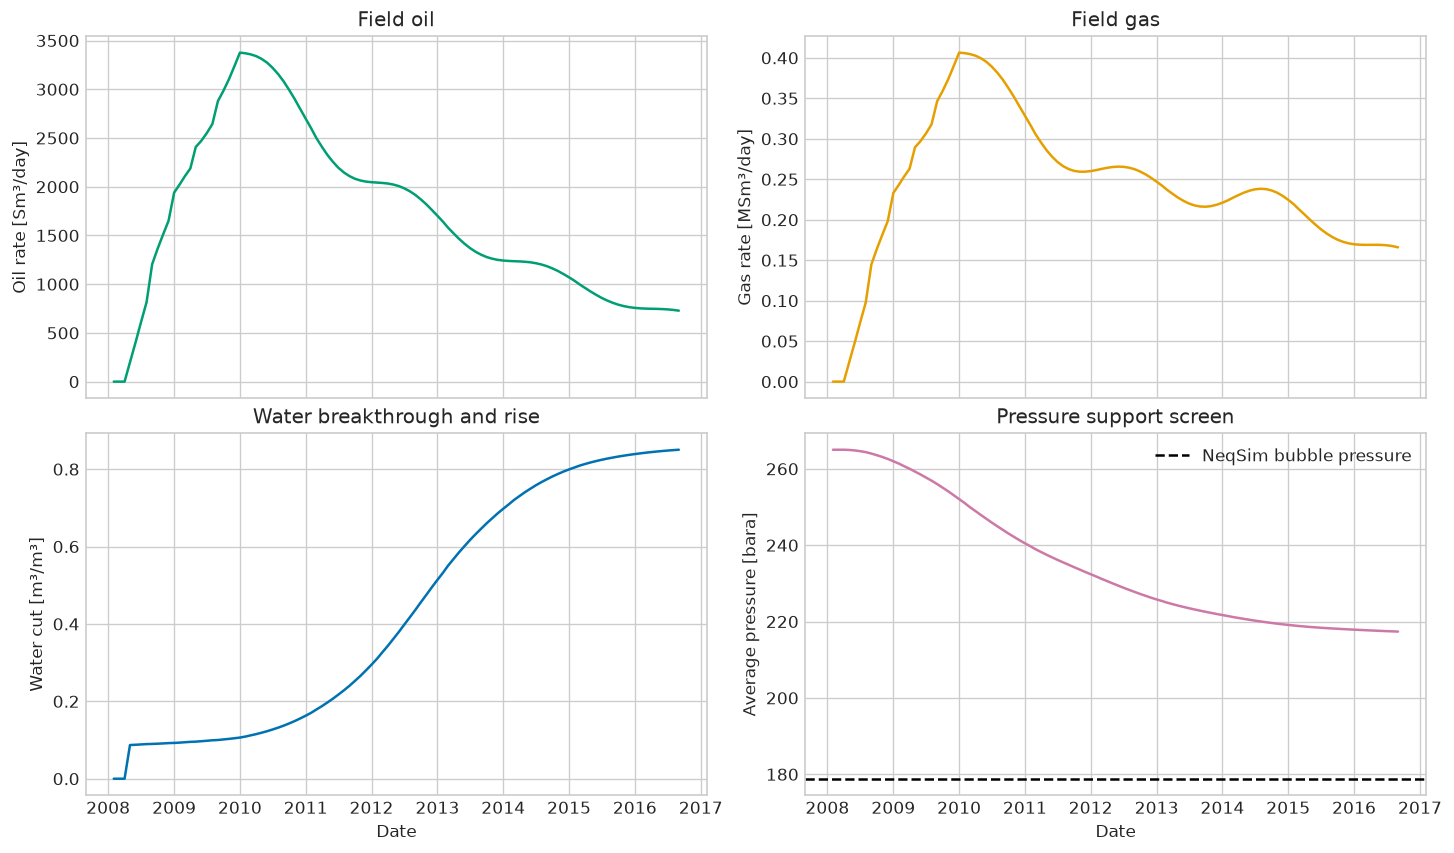

In [10]:
field_figure, field_axes = plt.subplots(
    2,
    2,
    figsize=(12.0, 7.0),
    sharex=True,
    constrained_layout=True,
)
field_axes[0, 0].plot(
    field_history["date"],
    field_history["oil_rate_Sm3_day"],
    color="#009E73",
)
field_axes[0, 0].set(ylabel="Oil rate [Sm³/day]", title="Field oil")
field_axes[0, 1].plot(
    field_history["date"],
    field_history["gas_rate_Sm3_day"] / 1.0e6,
    color="#E69F00",
)
field_axes[0, 1].set(ylabel="Gas rate [MSm³/day]", title="Field gas")
field_axes[1, 0].plot(
    field_history["date"],
    field_history["water_cut_fraction"],
    color="#0072B2",
)
field_axes[1, 0].set(
    ylabel="Water cut [m³/m³]",
    title="Water breakthrough and rise",
)
field_axes[1, 1].plot(
    field_history["date"],
    field_history["average_pressure_bara"],
    color="#CC79A7",
)
field_axes[1, 1].axhline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
    label="NeqSim bubble pressure",
)
field_axes[1, 1].set(
    ylabel="Average pressure [bara]",
    title="Pressure support screen",
)
field_axes[1, 1].legend()
for axis in field_axes[-1, :]:
    axis.set_xlabel("Date")
plt.show()


## 6. Reservoir forecast and facility-facing rates

A simple forecast separates subsurface potential from facility
constraints. For unconstrained potential $q_p(t)$ and capacities
$q_{o,\max}$, $q_{g,\max}$, and $q_{w,\max}$, the delivered rate is
the minimum of reservoir and surface envelopes. Notebook 5 performs
the full constrained integration; this notebook exports an
unconstrained reservoir case and uncertainty band.


In [11]:
forecast_dates = pd.date_range("2016-10-01", periods=72, freq="MS")
forecast_month = np.arange(len(forecast_dates))
final_oil = field_history["oil_rate_Sm3_day"].iloc[-1]
final_gas = field_history["gas_rate_Sm3_day"].iloc[-1]
final_water = field_history["water_rate_Sm3_day"].iloc[-1]
forecast = pd.DataFrame(
    {
        "date": forecast_dates,
        "oil_rate_Sm3_day": final_oil * np.exp(-0.018 * forecast_month),
        "gas_rate_Sm3_day": final_gas * np.exp(-0.012 * forecast_month),
        "water_rate_Sm3_day": final_water
        * (1.0 + 0.006 * forecast_month),
        "average_pressure_bara": np.maximum(
            field_history["average_pressure_bara"].iloc[-1]
            - 0.35 * forecast_month,
            90.0,
        ),
    }
)
forecast["water_cut_fraction"] = forecast["water_rate_Sm3_day"] / (
    forecast["oil_rate_Sm3_day"] + forecast["water_rate_Sm3_day"]
)
display(forecast.head())
display(forecast.tail())


,date,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,average_pressure_bara,water_cut_fraction
0,2016-10-01,728.261759,165911.928352,4135.564656,217.374292,0.850270
1,2016-11-01,715.270322,163932.883231,4160.378044,217.024292,0.853297
2,2016-12-01,702.510637,161977.444728,4185.191432,216.674292,0.856270
3,2017-01-01,689.978573,160045.331258,4210.004820,216.324292,0.859188
4,2017-02-01,677.670067,158136.264591,4234.818208,215.974292,0.862052


,date,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,average_pressure_bara,water_cut_fraction
67,2022-05-01,218.036078,74251.434359,5798.061648,193.924292,0.963758
68,2022-06-01,214.146539,73365.741930,5822.875036,193.574292,0.964528
69,2022-07-01,210.326386,72490.614294,5847.688424,193.224292,0.965281
70,2022-08-01,206.574380,71625.925432,5872.501812,192.874292,0.966019
71,2022-09-01,202.889307,70771.550827,5897.315200,192.524292,0.966741


In [12]:
history_contract_path = vc.write_contract(
    work_dir / "02_pvt_reservoir_forecast.json",
    {
        "discipline": "pvt-and-reservoir",
        "data_status": (
            "MEASURED_VOLVE"
            if source.measured_data_loaded
            else "DEMONSTRATION_FALLBACK"
        ),
        "eos": "SRK",
        "mixing_rule": "classic",
        "bubble_pressure_bara": bubble_pressure_bara,
        "dle_records": dle_table.to_dict("records"),
        "history_rows": len(field_history),
        "forecast_records": [
            {
                **record,
                "date": record["date"].isoformat(),
            }
            for record in forecast.to_dict("records")
        ],
        "limitations": [
            "material-balance teaching screen unless OPM Flow acceptance is run",
            "teaching fluid assay unless Marketplace PVT is selected",
            "no reserves classification",
        ],
    },
    source,
)
print(history_contract_path)


/workspace/scratch/95ecac0092cf/neqsim-colab-volve/notebooks/fielddevelopment/volve/work/02_pvt_reservoir_forecast.json


## 7. OPM Flow execution contract

The real-data path parses the selected deck, resolves includes
within the Marketplace volume, checks units and required keywords,
runs OPM Flow in a controlled case directory, and reads summary and
restart files with resdata or OPM Python. Required evidence includes
convergence, timestep cuts, mass balance, cell pressure and
saturation bounds, well constraints, and a comparison to measured
rates. This draft records that interface but does not claim an OPM
history match from the fallback fixture.


In [13]:
opm_acceptance = pd.DataFrame(
    {
        "gate": [
            "Marketplace deck and include paths selected",
            "deck parses with current OPM parser",
            "Flow exits successfully",
            "summary vectors finite and unit-audited",
            "restart saturations close and remain physical",
            "history residuals reported by well and field",
        ],
        "fallback_status": [
            "not applicable",
            "not executed",
            "not executed",
            "not executed",
            "not executed",
            "demonstrated with transparent screen",
        ],
        "required_for_measured_run": [True] * 6,
    }
)
display(opm_acceptance)


,gate,fallback_status,required_for_measured_run
0,Marketplace deck and include paths selected,not applicable,True
1,deck parses with current OPM parser,not executed,True
2,Flow exits successfully,not executed,True
3,summary vectors finite and unit-audited,not executed,True
4,restart saturations close and remain physical,not executed,True
5,history residuals reported by well and field,demonstrated with transparent screen,True


In [14]:
checks = {
    "fluid composition closes": abs(composition_sum - 1.0) < 1.0e-12,
    "bubble pressure is finite": np.isfinite(bubble_pressure_bara),
    "bubble pressure is physical": 20.0 < bubble_pressure_bara < 320.0,
    "pressure sweep finite where oil exists": bool(
        pressure_sweep["oil_density_kg_m3"].dropna().gt(0.0).all()
    ),
    "DLE table finite": np.isfinite(
        dle_table.select_dtypes(include=[np.number]).to_numpy()
    ).all(),
    "field rates non-negative": bool(
        field_history[
            ["oil_rate_Sm3_day", "gas_rate_Sm3_day", "water_rate_Sm3_day"]
        ]
        .ge(0.0)
        .all()
        .all()
    ),
    "forecast water cut physical": bool(
        forecast["water_cut_fraction"].between(0.0, 1.0).all()
    ),
    "handoff exists": history_contract_path.is_file(),
}
validation = pd.DataFrame(
    {"check": checks.keys(), "passed": checks.values()}
)
display(validation)
if not validation["passed"].all():
    raise AssertionError(validation.loc[~validation["passed"], "check"].tolist())
print(f"All {len(checks)} PVT and reservoir checks passed.")


All 8 PVT and reservoir checks passed.


,check,passed
0,fluid composition closes,True
1,bubble pressure is finite,True
2,bubble pressure is physical,True
3,pressure sweep finite where oil exists,True
4,DLE table finite,True
5,field rates non-negative,True
6,forecast water cut physical,True
7,handoff exists,True


## Interpretation and next notebook

NeqSim supplies the compositional fluid and black-oil source
properties; OPM Flow owns spatial pressure and saturation evolution;
measured Volve production tests the model. Notebook 3 combines the
rate and pressure envelope with trajectories, completions, IPR/VLP,
network hydraulics, thermal behavior, hydrate margin, erosion, and
shutdown cooldown to determine what reaches the facilities.
